In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [2]:
# Load Dataset

df = pd.read_csv("daily_gym_attendance_workout_data.csv")

# Display first 5 rows
df.head()

,member_id,visit_date,age,gender,membership_type,workout_type,workout_duration_minutes,calories_burned,check_in_time,attendance_status
0,1,2024-10-11,64,Other,Annual,HIIT,28,171,20:04,Absent
1,2,2024-06-01,65,Female,Quarterly,Strength Training,72,650,19:17,Absent
2,3,2024-06-13,45,Male,Quarterly,Cardio,70,633,7:24,Absent
3,4,2024-02-05,35,Female,Monthly,CrossFit,64,362,7:18,Absent
4,5,2024-07-13,26,Female,Quarterly,Yoga,31,262,11:22,Absent


In [4]:
# Check all values
print(df.isna())

      member_id  visit_date    age  gender  membership_type  workout_type  \
0         False       False  False   False            False         False   
1         False       False  False   False            False         False   
2         False       False  False   False            False         False   
3         False       False  False   False            False         False   
4         False       False  False   False            False         False   
...         ...         ...    ...     ...              ...           ...   
2595      False       False  False   False            False         False   
2596      False       False  False   False            False         False   
2597      False       False  False   False            False         False   
2598      False       False  False   False            False         False   
2599      False       False  False   False            False         False   

      workout_duration_minutes  calories_burned  check_in_time  \
0        

In [5]:
print(df.isna().sum())

member_id                   0
visit_date                  0
age                         0
gender                      0
membership_type             0
workout_type                0
workout_duration_minutes    0
calories_burned             0
check_in_time               0
attendance_status           0
dtype: int64


In [6]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

In [7]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (2600, 10) 

number of rows:  2600
number of columns:  10


In [8]:
# viewing the data types of columns
df.dtypes

member_id                    int64
visit_date                  object
age                          int64
gender                      object
membership_type             object
workout_type                object
workout_duration_minutes     int64
calories_burned              int64
check_in_time               object
attendance_status           object
dtype: object

In [9]:
df['visit_date'] = pd.to_datetime(df['visit_date'], errors='coerce')
df['calories_burned'] = pd.to_numeric(df['calories_burned'], errors='coerce')
df.dtypes

member_id                            int64
visit_date                  datetime64[ns]
age                                  int64
gender                              object
membership_type                     object
workout_type                        object
workout_duration_minutes             int64
calories_burned                      int64
check_in_time                       object
attendance_status                   object
dtype: object

In [10]:
# Statistical summary
df.describe(include='all')

,member_id,visit_date,age,gender,membership_type,workout_type,workout_duration_minutes,calories_burned,check_in_time,attendance_status
count,2600.000000,2600,2600.000000,2600,2600,2600,2600.000000,2600.000000,2600,2600
unique,NaN,NaN,NaN,3,3,5,NaN,NaN,982,2
top,NaN,NaN,NaN,Female,Annual,Strength Training,NaN,NaN,6:44,Absent
freq,NaN,NaN,NaN,886,903,559,NaN,NaN,9,1350
mean,1300.500000,2024-07-05 04:39:41.538461440,41.947308,NaN,NaN,NaN,70.162692,523.775385,NaN,NaN
min,1.000000,2024-01-01 00:00:00,18.000000,NaN,NaN,NaN,20.000000,102.000000,NaN,NaN
25%,650.750000,2024-04-03 00:00:00,30.000000,NaN,NaN,NaN,46.000000,329.000000,NaN,NaN
50%,1300.500000,2024-07-07 00:00:00,42.000000,NaN,NaN,NaN,70.000000,504.000000,NaN,NaN
75%,1950.250000,2024-10-06 06:00:00,54.000000,NaN,NaN,NaN,94.000000,691.250000,NaN,NaN
max,2600.000000,2024-12-31 00:00:00,65.000000,NaN,NaN,NaN,120.000000,1186.000000,NaN,NaN


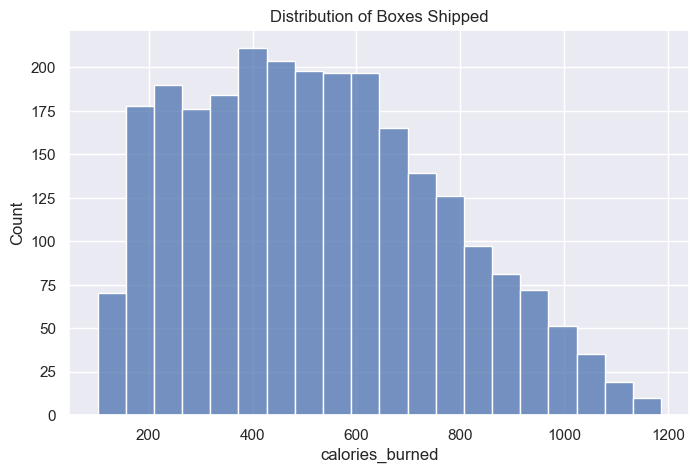

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['calories_burned'], bins=20)
plt.title("Distribution of Boxes Shipped")
plt.show()

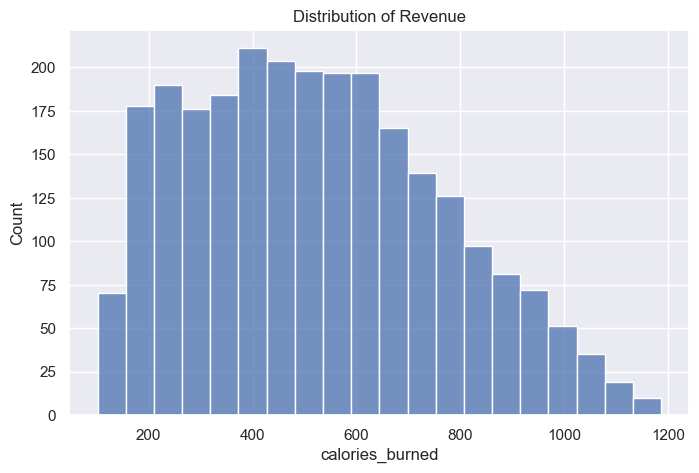

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['calories_burned'], bins=20)
plt.title("Distribution of Revenue")
plt.show()

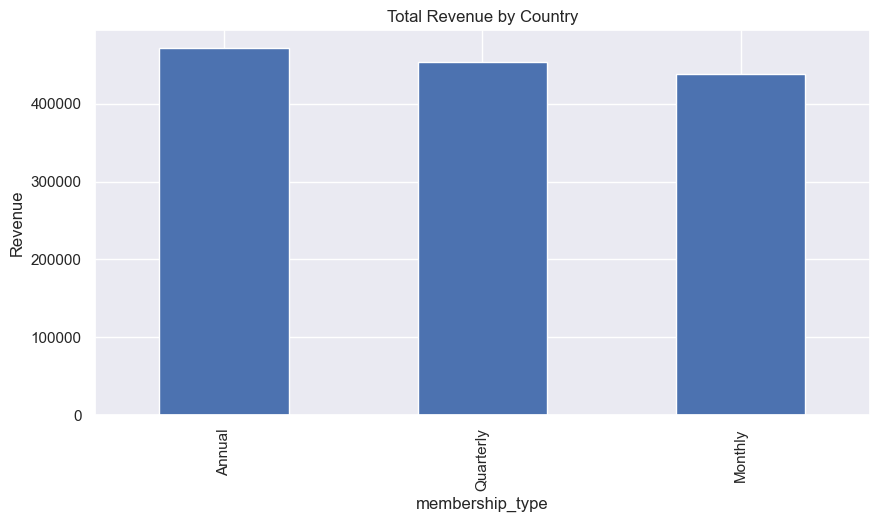

membership_type
Annual       470941
Quarterly    453007
Monthly      437868
Name: calories_burned, dtype: int64

In [13]:
country_revenue = df.groupby('membership_type')['calories_burned'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
country_revenue.plot(kind='bar')
plt.title("Total Revenue by Country")
plt.ylabel("Revenue")
plt.show()

country_revenue

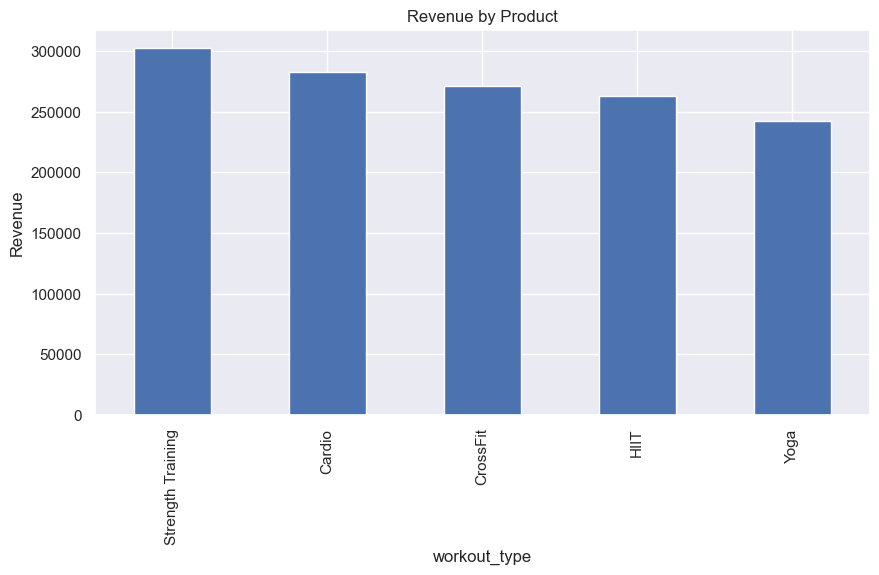

workout_type
Strength Training    302210
Cardio               282938
CrossFit             271019
HIIT                 262994
Yoga                 242655
Name: calories_burned, dtype: int64

In [15]:
product_revenue = df.groupby('workout_type')['calories_burned'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
product_revenue.plot(kind='bar')
plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.show()

product_revenue

In [17]:
salesperson_revenue = df.groupby('membership_type')['calories_burned'].sum().sort_values(ascending=False)
salesperson_revenue.head(10)

membership_type
Annual       470941
Quarterly    453007
Monthly      437868
Name: calories_burned, dtype: int64

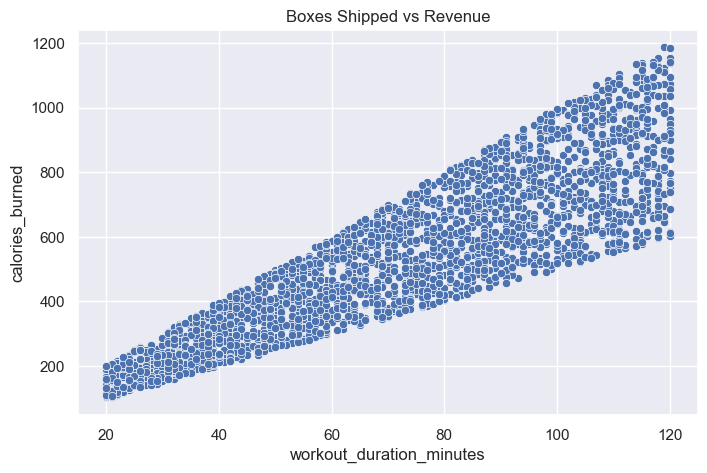

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='workout_duration_minutes', y='calories_burned', data=df)
plt.title("Boxes Shipped vs Revenue")
plt.show()

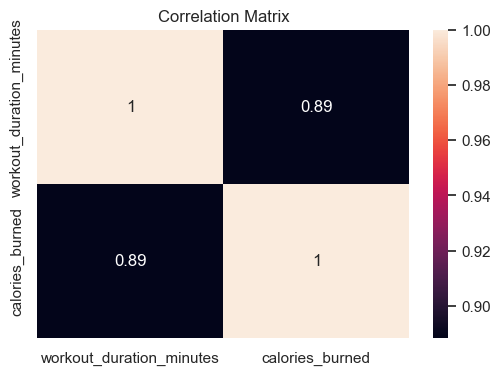

In [20]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['workout_duration_minutes', 'calories_burned']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

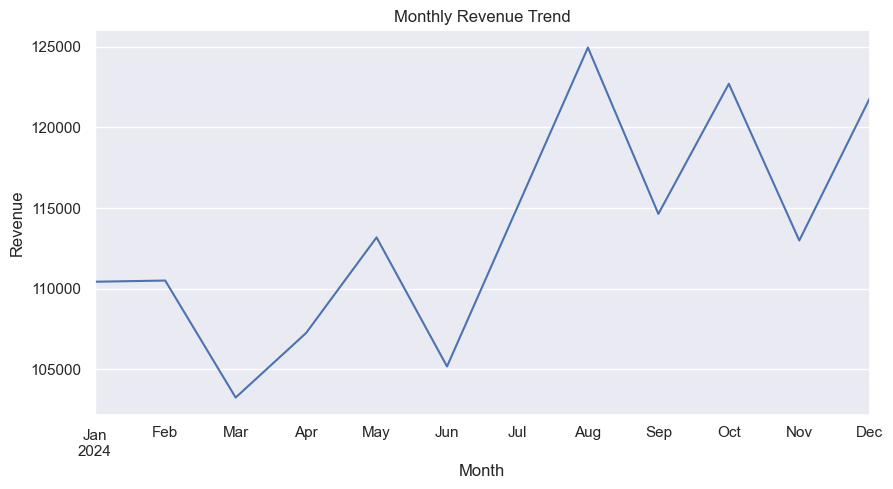

In [24]:
df['Month'] = df['visit_date'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['calories_burned'].sum()

plt.figure(figsize=(10,5))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()